In [1]:
# file extraction with .xml only 
from pathlib import Path

team = 'Utah St. Aggies'
data_dir = Path(
    f"/Users/hungduong/Documents/UofU-Soccer-Mbb/UofU Soccer Analytics/2026_data/{team}"
)

# Separate player/team files
team_based_files = sorted(
    f.name for f in data_dir.glob("* (Team-based).xml")
)
player_based_files = sorted(
    f.name for f in data_dir.glob("* (Player-based).xml")
)

# Read player/ team files
from functions import (
    parse_player_data_xml,
    parse_team_data_xml,
)
player_data = parse_player_data_xml(
    str(data_dir),
    files=player_based_files,
    numeric_cols=["ID", "Start Time", "End Time"],
)
team_data = parse_team_data_xml(
    str(data_dir),
    files=team_based_files,
    numeric_cols=[
        "start",
        "end",
        "11 - Start location X",
        "12 - Start location Y",
        "13 - Duration",
        "15 - End location X",
        "16 - End location Y",
    ],
)



# Player dict with time and keeper list
keeper = [
    "99. Grashoff",
    "1. Nystrom",
]

player_minutes = {
    "2. Sofonia": 418,
    "21. Espinoza": 196,
    "15. Winder": 184,
    "6. Sellers": 150,
    "26. Yoneda": 144,
    "7. Vigil": 54,
    "4. Emmetsberger": 24,
    "28. Wilson": 418,
    "41. Winder": 382,
    "24. Reitz": 313,
    "13. Hirai": 230,
    "12. Lopez": 214,
    "25. Barrera": 207,
    "14. Diamond": 206,
    "30. Alcala": 38,
    "9. Christian": 217,
    "5. Hendrix": 200,
    "19. Miller": 193,
    "3. Mullenmeister": 192,
    "10. Sellers": 173,
    "11. Hironaka": 2,
}

# Data preprocessing

#### Import libraries

In [2]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mplsoccer import Pitch, VerticalPitch
import os
import glob
from typing import Union, List, Optional
from collections import defaultdict
from typing import Union, List, Optional, Dict
import gzip, re

from functions import (
    compute_shot_chain_scores,
    parse_player_data_xml,
    add_team_name,
    plot_keeper_dist,
    parse_team_data_xml,
)

#### Functions

In [3]:
# Compute shotting chain function
def compute_shot_chain_scores(
    df,
    k=4,
    weights: list = None,                    # e.g., [0.1, 0.1, 0.2, 0.5] (farthest -> shooter)
    terminal_action='Shot',
    team=None,                               # filter to a specific team; None = all teams
    unique_in_chain=True,                    # don't credit the same player twice within a chain
    eligible_types=None,                     # which actions count before the shot
    id_col='ID',
    team_col='Team',
    player_col='Player Code',
    action_col='Action Type',
    labels_col='Additional Labels',
    goal_shot_weight=0.7,                    # shooter weight to use when the shot is a Goal
    goal_weight_mode='override'              # 'override' (default) or 'bonus'
):
    """
    Aggregate weighted credits to the last `k` players in each shot chain (including the shooter).
    Returns a DataFrame with columns: [Team, Player, TotalScore].

    weights: list of length k, ordered from farthest in the chain to the shooter.
             If a chain has < k players, the *suffix* of weights is used so the shooter
             always aligns with the last weight.
    If the shot has 'Goal' in `labels_col`:
      - goal_weight_mode='override' -> replace shooter weight with `goal_shot_weight`
      - goal_weight_mode='bonus'    -> add `goal_shot_weight` to the shooter weight
    """
    # defaults
    if eligible_types is None:
        eligible_types = {'Touch', 'Pass', 'Duel', 'Free kick', 'Throw in',
       'Interception', 'Clearance', 'Goal kick', 'Corner',
       'Shot against', }
    if weights is None:
        weights = [0.1, 0.1, 0.2, 0.5]
    if len(weights) != k:
        raise ValueError(f"`weights` length ({len(weights)}) must equal k ({k}).")

    df = df.copy().sort_values(id_col).reset_index(drop=True)

    # shots (optionally by team)
    shot_mask = df[action_col].eq(terminal_action)
    if team is not None:
        shot_mask &= df[team_col].eq(team)
    shot_idxs = df.index[shot_mask].tolist()

    totals = defaultdict(float)

    for si in shot_idxs:
        shot_row  = df.loc[si]
        shot_team = shot_row[team_col]
        shooter   = shot_row[player_col]

        # build chain: start with shooter (end of chain)
        chain_players = [shooter]
        seen = {shooter} if unique_in_chain else set()

        # walk backward through same-team, eligible actions to gather up to k-1 more players
        j = si - 1
        while j >= 0 and len(chain_players) < k and df.at[j, team_col] == shot_team:
            if df.at[j, action_col] in eligible_types:
                p = df.at[j, player_col]
                if (not unique_in_chain) or (p not in seen):
                    chain_players.append(p)   # closest-first while walking backward
                    seen.add(p)
            j -= 1

        # farthest -> shooter to match weights
        chain_players = list(reversed(chain_players))
        m = len(chain_players)
        w = weights[-m:]  # keep shooter aligned to the last weight

        # goal-sensitive shooter weight
        labs = str(shot_row.get(labels_col) or '').lower()
        if 'goal' in labs:
            if goal_weight_mode == 'override':
                w[-1] = goal_shot_weight
            elif goal_weight_mode == 'bonus':
                w[-1] = w[-1] + goal_shot_weight

        # accumulate
        for player, weight in zip(chain_players, w):
            totals[(shot_team, player)] += weight

    out = (
        pd.DataFrame([(t, p, s) for (t, p), s in totals.items()],
                     columns=[team_col, player_col, 'TotalScore'])
        .sort_values([team_col, 'TotalScore'], ascending=[True, False])
        .reset_index(drop=True)
    )
    return out


In [4]:
# Read player data file(s) function

def parse_player_data_xml(
    folder: Union[str, Path],
    files: Union[str, List[str]],
    numeric_cols: Optional[List[str]] = None,
    combine: bool = True
) -> Union[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Parse one or many 'Player-based' soccer XML files into pandas DataFrame(s).
    - Tolerant to gzip, BOM/junk bytes, and encoding quirks
    - Skips bad files but processes the rest
    - Adds 'Source File' when combine=True
    """

    # ---- helpers ----
    ILLEGAL_XML_RE = re.compile(r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]")

    def _safe_cast(val, typ):
        try:
            return typ(val) if val is not None else None
        except (ValueError, TypeError):
            return None

    def _read_xml_text_robust(path: Path) -> str:
        raw = path.read_bytes()
        # gzip magic
        if raw[:2] == b"\x1f\x8b":
            raw = gzip.decompress(raw)
        # decode (handle BOM with utf-8-sig)
        for enc in ("utf-8-sig", "utf-16", "cp1252"):
            try:
                text = raw.decode(enc)
                break
            except UnicodeDecodeError:
                continue
        else:
            text = raw.decode("latin-1", errors="replace")
        # strip anything before first '<' and illegal control chars
        i = text.find("<")
        if i > 0:
            text = text[i:]
        return ILLEGAL_XML_RE.sub("", text)

    def _parse_one(path: Path) -> pd.DataFrame:
        # Load + parse root
        text = _read_xml_text_robust(path)
        try:
            root = ET.fromstring(text)
        except ET.ParseError as e:
            # HTML or non-XML? (don't crash—just skip)
            head = text[:80].strip().replace("\n", " ")
            raise ValueError(f"{path.name}: not well-formed XML ({e}); head starts: {head!r}")

        # Extract rows from <instance> nodes
        rows = []
        for inst in root.findall(".//instance"):
            row = {
                "ID": _safe_cast(inst.findtext("ID"), int),
                "Player Code": inst.findtext("code"),
                "Start Time": _safe_cast(inst.findtext("start"), float),
                "End Time": _safe_cast(inst.findtext("end"), float),
            }
            labels = [lab.findtext("text") for lab in inst.findall("label") if lab.findtext("text")]
            row["Action Type"] = labels[0] if labels else None
            row["Additional Labels"] = ", ".join(labels[1:]) if len(labels) > 1 else ""
            rows.append(row)

        df = pd.DataFrame(rows)
        if numeric_cols:
            for c in numeric_cols:
                if c in df.columns:
                    df[c] = pd.to_numeric(df[c], errors="coerce")
        return df.reset_index(drop=True)

    def _expand_paths(folder: Path, items: List[str]) -> List[Path]:
        out = []
        for it in items:
            if any(ch in it for ch in "*?[]"):            # glob support if you need it
                out.extend(sorted((folder).glob(it)))
            else:
                out.append((folder / it))
        # dedupe but keep order
        seen, uniq = set(), []
        for p in out:
            if p not in seen:
                seen.add(p); uniq.append(p)
        return uniq

    # ---- main ----
    folder = Path(folder)
    if isinstance(files, str):
        files = [files]
    paths = _expand_paths(folder, files)
    if not paths:
        raise FileNotFoundError(f"No files matched {files} in {folder}")

    if combine:
        frames, skipped = [], []
        for p in paths:
            try:
                if not p.exists():
                    skipped.append(f"{p.name}: missing file")
                    continue
                df = _parse_one(p)
                if df.empty:
                    skipped.append(f"{p.name}: parsed but no <instance> rows")
                    continue
                df.insert(0, "Source File", p.name)
                frames.append(df)
            except Exception as e:
                skipped.append(str(e))
        if skipped:
            print("⚠️ Skipped/issue files:\n - " + "\n - ".join(skipped))
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(
            columns=["Source File","ID","Player Code","Start Time","End Time","Action Type","Additional Labels"]
        )
    else:
        out, skipped = {}, []
        for p in paths:
            try:
                if not p.exists():
                    skipped.append(f"{p.name}: missing file"); continue
                df = _parse_one(p)
                out[p.name] = df
            except Exception as e:
                skipped.append(str(e))
        if skipped:
            print("⚠️ Skipped/issue files:\n - " + "\n - ".join(skipped))
        return out


In [5]:
# Function adding appropriate team name to 
def add_team_name(df, first_team, first_team_players,
                  second_team=None, second_team_players=None,
                  player_code="Player Code"):
    mapping = {p.strip(): first_team for p in (first_team_players or [])}
    if second_team and second_team_players:
        mapping.update({p.strip(): second_team for p in second_team_players})
    df = df.copy()
    df[player_code] = df[player_code].astype(str).str.strip()
    df["Team"] = df[player_code].map(mapping)
    return df


In [6]:
# Team data xml function
def parse_team_data_xml(
    folder: Union[str, os.PathLike],
    files: Union[str, List[str]],
    numeric_cols: Optional[List[str]] = None
) -> pd.DataFrame:
    """
    Parse one or multiple 'Team-based' soccer XML files into a pandas DataFrame.

    Parameters
    ----------
    folder : str | PathLike
        Directory containing the XML file(s).
    files : str | List[str]
        - Single filename (e.g., "match.xml")
        - List of filenames (["a.xml", "b.xml"])
        - Or glob pattern(s) (e.g., "*.xml" or ["Utah*.xml", "Cal*.xml"])
    numeric_cols : List[str], optional
        Extra columns to coerce to numeric (errors='coerce'). Common
        team-based coords are auto-included if present.

    Returns
    -------
    pd.DataFrame
        Combined rows from all files with columns:
        ['match_name', 'ID', 'code', 'start', 'end', labels...]
        If a label group appears multiple times, values are joined with ", ".
    """
    # Resolve list of paths from files arg
    if isinstance(files, str):
        files = [files]

    paths: List[str] = []
    for pat in files:
        full_pat = os.path.join(folder, pat)
        matches = glob.glob(full_pat)
        if not matches and os.path.exists(full_pat):
            matches = [full_pat]
        paths.extend(matches)

    # Deduplicate while preserving order
    seen = set()
    uniq_paths = []
    for p in paths:
        if p not in seen:
            uniq_paths.append(p)
            seen.add(p)

    if not uniq_paths:
        raise FileNotFoundError("No XML files matched. Check folder and filenames/globs.")

    rows = []

    for file in uniq_paths:
        try:
            tree = ET.parse(file)
            root = tree.getroot()
        except Exception as e:
            print(f"[WARN] Skipping '{file}' (parse error: {e})")
            continue

        match_name = os.path.splitext(os.path.basename(file))[0]

        all_instances = root.find("ALL_INSTANCES")
        if all_instances is None:
            print(f"[WARN] '{file}' has no <ALL_INSTANCES>; skipping.")
            continue

        for inst in all_instances.findall("instance"):
            row = {
                "match_name": match_name,
                "ID": (inst.findtext("ID") or "").strip(),
                "code": (inst.findtext("code") or "").strip(),
                "start": (inst.findtext("start") or "").strip(),
                "end": (inst.findtext("end") or "").strip(),
            }

            # Collect all labels; if the same group appears multiple times, join texts
            group_values = defaultdict(list)
            for label in inst.findall("label"):
                group = (label.findtext("group") or "").strip()
                text = (label.findtext("text") or "").strip()
                if not group:
                    continue
                if text and text not in group_values[group]:
                    group_values[group].append(text)

            # Flatten label groups into comma-separated strings
            for g, vals in group_values.items():
                row[g] = ", ".join(vals)

            rows.append(row)

    df = pd.DataFrame(rows).reset_index(drop=True)

    # Convert likely numeric columns if they exist
    default_numeric = [
        "11 - Start location X",
        "12 - Start location Y",
        "13 - Duration",
        "15 - End location X",
        "16 - End location Y",
        "start",
        "end",
    ]
    if numeric_cols:
        default_numeric.extend(numeric_cols)

    for col in set(default_numeric):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


In [7]:
# Keeper distribution
def plot_keeper_dist(df, col='10 - Players', exclude=None):
    exclude_norm = {x.casefold() for x in (exclude or [])}
    s = (df[col].str.split(',').explode().dropna().str.strip())
    s = s[s.ne('')]
    if exclude_norm:
        s = s[~s.str.casefold().isin(exclude_norm)]
    ax = s.value_counts().plot(kind='bar', figsize=(10,5))
    ax.set_title('Keepers distribution to player frequency')
    plt.tight_layout(); plt.show()
    return ax

# Analytics

#### Corners 

Filter for corner kicks in team_data

In [8]:

team_corners = team_data[team_data['code'].str.contains(f"{team} - Corners")]
pd.set_option('display.max_colwidth', None)
team_corners.head()

,match_name,ID,code,start,end,01 - Location third,02 - Location flank,03 - End location third,04 - End location flank,05 - Length,...,10 - Players,11 - Start location X,12 - Start location Y,13 - Duration,14 - Formation,15 - End location X,16 - End location Y,08 - Transition,07 - Outcome,09 - xG
771,Kansas Jayhawks - Utah St. Aggies 2-0 (Team-based),772,Utah St. Aggies - Corners,3468.719,3471.128,Final third,Left flank,Final third,Center,Short,...,19. Miller,105.0,0.0,1.0,4-2-3-1,6.0,40.0,NaN,NaN,NaN
806,Kansas Jayhawks - Utah St. Aggies 2-0 (Team-based),807,Utah St. Aggies - Corners,3644.593,3646.958,Final third,Left flank,Final third,Center,Short,...,12. Lopez,105.0,0.0,1.0,4-2-3-1,4.0,38.0,NaN,NaN,NaN
1649,Utah St. Aggies - Michigan Wolverines 2-2 (Team-based),183,Utah St. Aggies - Corners,968.826,979.860,Final third,Right flank,Final third,Center,Short,...,"28. Wilson, 41. Winder, 9. Christian, 24. Reitz",105.0,68.0,7.0,4-2-3-1,11.0,33.0,NaN,Shot,from 0.1 to 0.35
1965,Utah St. Aggies - Michigan Wolverines 2-2 (Team-based),499,Utah St. Aggies - Corners,2813.822,2819.285,Final third,Left flank,Final third,Center,Short,...,"10. Sellers, 12. Lopez, 28. Wilson",105.0,0.0,4.0,4-2-3-1,11.0,37.0,NaN,NaN,NaN
2005,Utah St. Aggies - Michigan Wolverines 2-2 (Team-based),539,Utah St. Aggies - Corners,3011.297,3018.083,Final third,Left flank,Final third,Center,Short,...,"12. Lopez, 21. Espinoza, 14. Diamond",105.0,0.0,5.0,4-3-3,18.0,35.0,NaN,NaN,NaN


Further filter by outcome for visualization

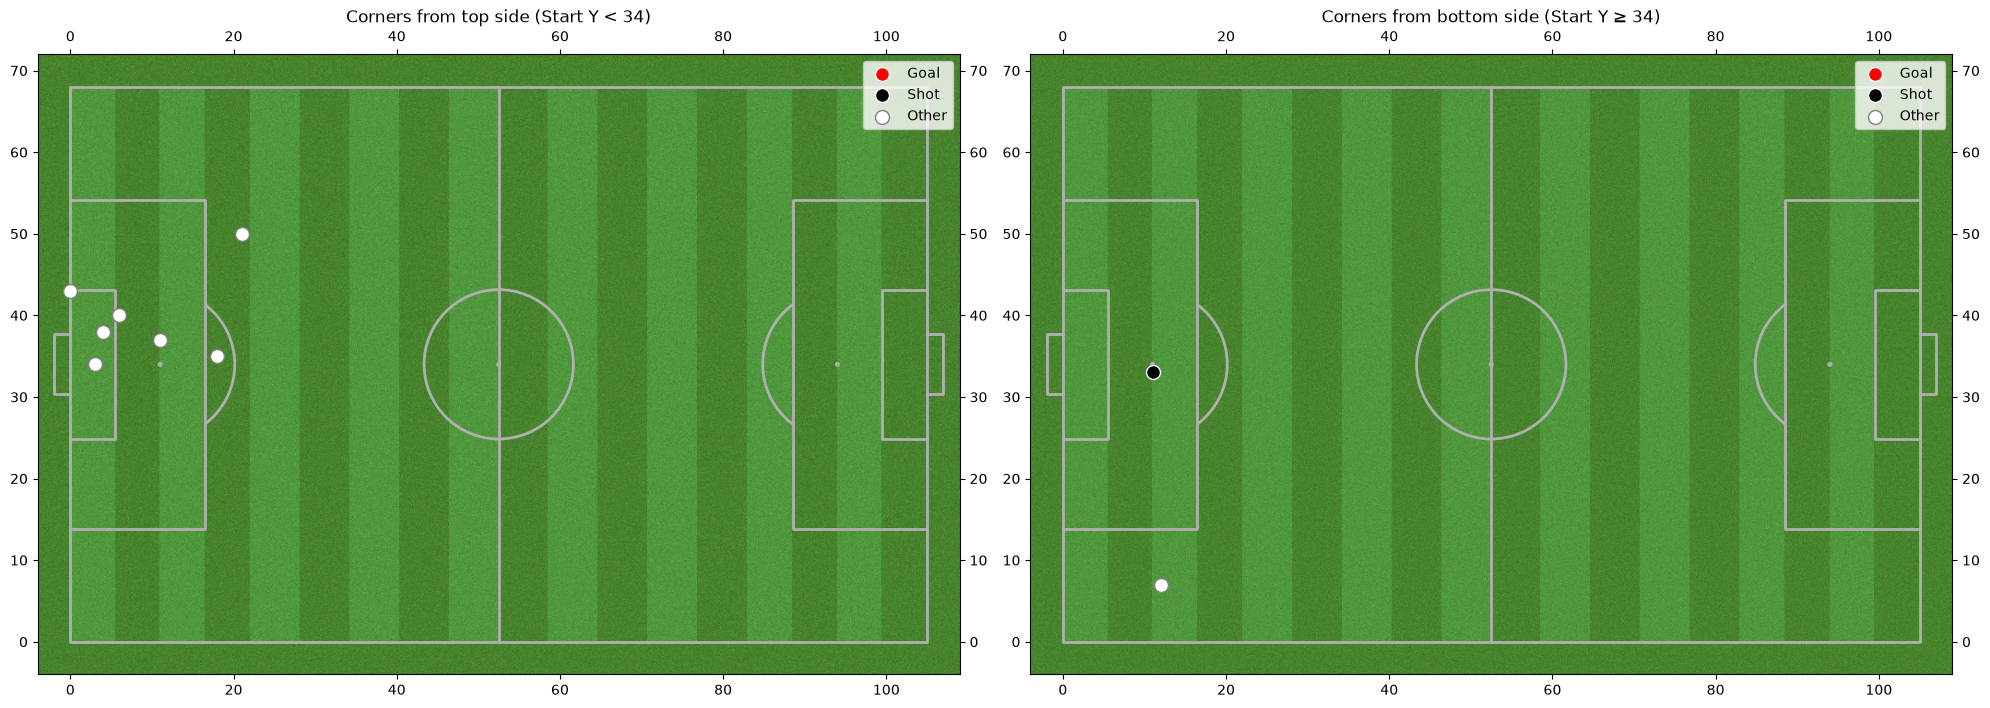

In [9]:
# Split corners by side of the pitch, using the START Y-coordinate
top_side_corners = team_corners[
    team_corners["12 - Start location Y"] < 34
]

bottom_side_corners = team_corners[
    team_corners["12 - Start location Y"] >= 34
]

pitch = Pitch(
    pitch_type="uefa",
    pitch_color="grass",
    stripe=True,
    goal_type="box",
    label=True,
    axis=True,
    tick=True,
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Top-side corners
pitch.draw(ax=axes[0])

for outcome, color, edgecolor, label in [
    ("Goal", "red", "white", "Goal"),
    ("Shot", "black", "white", "Shot"),
]:
    data = top_side_corners[top_side_corners["07 - Outcome"] == outcome]
    axes[0].scatter(
        data["15 - End location X"],
        data["16 - End location Y"],
        c=color, s=100, edgecolors=edgecolor, label=label
    )

data = top_side_corners[
    ~top_side_corners["07 - Outcome"].isin(["Goal", "Shot"])
]
axes[0].scatter(
    data["15 - End location X"],
    data["16 - End location Y"],
    c="white", s=100, edgecolors="gray", label="Other"
)

axes[0].set_title("Corners from top side (Start Y < 34)")
axes[0].legend()


# Bottom-side corners
pitch.draw(ax=axes[1])

for outcome, color, edgecolor, label in [
    ("Goal", "red", "white", "Goal"),
    ("Shot", "black", "white", "Shot"),
]:
    data = bottom_side_corners[
        bottom_side_corners["07 - Outcome"] == outcome
    ]
    axes[1].scatter(
        data["15 - End location X"],
        data["16 - End location Y"],
        c=color, s=100, edgecolors=edgecolor, label=label
    )

data = bottom_side_corners[
    ~bottom_side_corners["07 - Outcome"].isin(["Goal", "Shot"])
]
axes[1].scatter(
    data["15 - End location X"],
    data["16 - End location Y"],
    c="white", s=100, edgecolors="gray", label="Other"
)

axes[1].set_title("Corners from bottom side (Start Y ≥ 34)")
axes[1].legend()

plt.tight_layout()
plt.show()


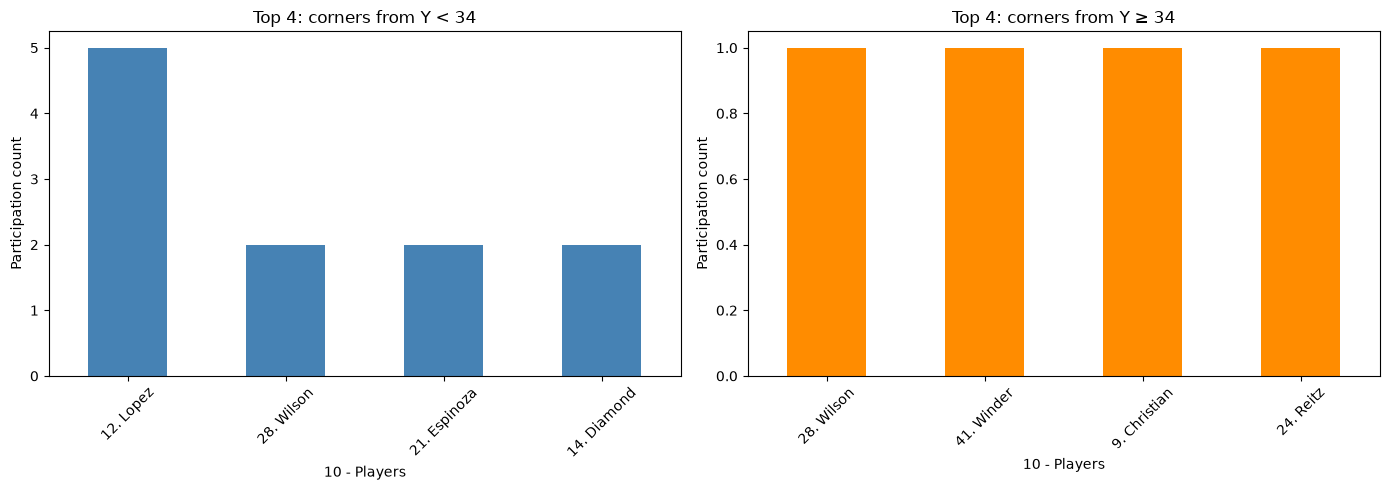

In [10]:
# Split by corner side: Y < 34 versus Y >= 34
side_a_corners = team_corners[team_corners["12 - Start location Y"] < 34]
side_b_corners = team_corners[team_corners["12 - Start location Y"] >= 34]

side_a_players = (
    side_a_corners["10 - Players"].dropna()
    .str.split(",").explode().str.strip()
    .value_counts().head(4)
)

side_b_players = (
    side_b_corners["10 - Players"].dropna()
    .str.split(",").explode().str.strip()
    .value_counts().head(4)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

side_a_players.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Top 4: corners from Y < 34")
axes[0].set_ylabel("Participation count")
axes[0].tick_params(axis="x", rotation=45)

side_b_players.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Top 4: corners from Y ≥ 34")
axes[1].set_ylabel("Participation count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Goal kicks

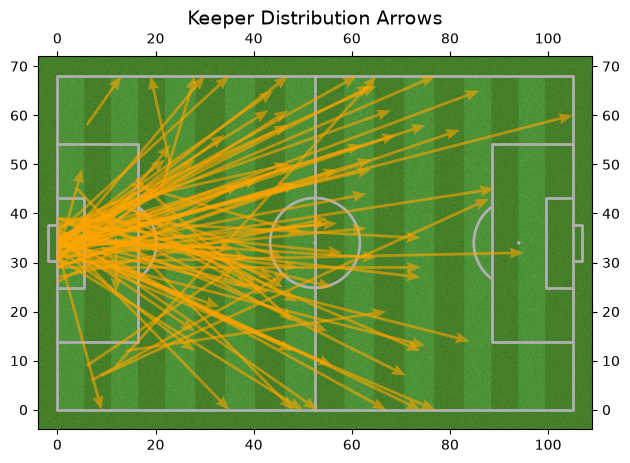

In [11]:
team_keep_distribution = team_data[(team_data['code']==f'{team} - Goalkeeper distributions')]

# Draw pitch
pitch = Pitch(
    pitch_length=105, pitch_width=68, pitch_type='uefa',
    pitch_color='grass', stripe=True, goal_type='box',
    #half=True, 
    label=True, axis=True, tick=True
)
fig, ax = pitch.draw()

# Draw arrows
pitch.arrows(
    xstart=team_keep_distribution['11 - Start location X'],
    ystart=team_keep_distribution['12 - Start location Y'],
    xend=team_keep_distribution['15 - End location X'],
    yend=team_keep_distribution['16 - End location Y'],
    color='orange',
    ax=ax,
    width=2,
    headwidth=4,
    alpha=0.6,
    zorder=3
)

plt.title("Keeper Distribution Arrows", fontsize=14)
plt.show()

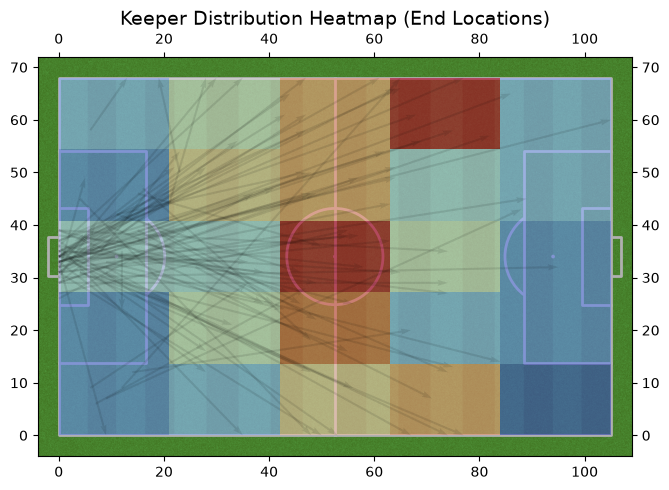

In [12]:
# Extract coordinates
x_start = team_keep_distribution['11 - Start location X']
y_start = team_keep_distribution['12 - Start location Y']
x_end = team_keep_distribution['15 - End location X']
y_end = team_keep_distribution['16 - End location Y']

# Set up the pitch
pitch = Pitch(
    pitch_length=105, pitch_width=68, pitch_type='uefa',
    pitch_color='grass', stripe=True, goal_type='box',
    label=True, axis=True, tick=True
)

fig, ax = pitch.draw(figsize=(8, 5))

# Plot heatmap of start locations
bin_stat = pitch.bin_statistic(x_end, y_end, statistic='count', bins=(5, 5))
pitch.heatmap(bin_stat, ax=ax, cmap='coolwarm', alpha=0.6)

# Optional: overlay arrows (lighter and less prominent)
pitch.arrows(
    xstart=x_start,
    ystart=y_start,
    xend=x_end,
    yend=y_end,
    color='black',
    ax=ax,
    width=1.5,
    headwidth=3,
    alpha=0.1,   # Lower alpha to avoid clutter
    zorder=2
)

# Title
plt.title("Keeper Distribution Heatmap (End Locations)", fontsize=14)
plt.show()


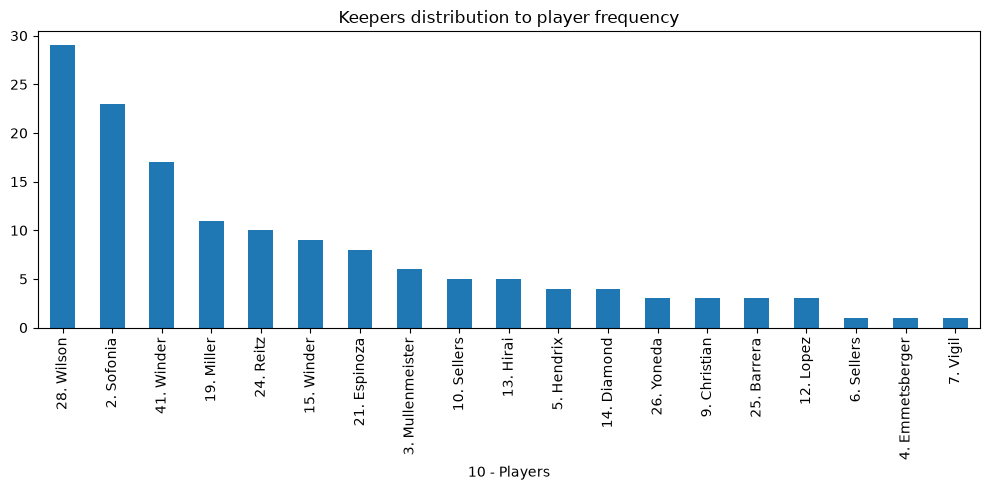

<Axes: title={'center': 'Keepers distribution to player frequency'}, xlabel='10 - Players'>

In [13]:
plot_keeper_dist(team_keep_distribution, exclude=keeper)


#### Get data Player

In [14]:
player_data = add_team_name(player_data, first_team=team,
              first_team_players= player_minutes
             
             )

player_data.head(10)

,Source File,ID,Player Code,Start Time,End Time,Action Type,Additional Labels,Team
0,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,1,13. Hirai,-2.000,4.431,Pass,"Back pass, Short or medium pass",Utah St. Aggies
1,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,2,14. Diamond,1.431,6.930,Pass,"Forward pass, Long pass, Loss, Pass to final third, Progressive run, Carry",Utah St. Aggies
2,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,3,27. De Fini,3.930,9.187,Pass,"Head pass, Loss, Progressive pass, Short or medium pass",NaN
3,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,4,14. Diamond,6.187,11.187,Pass,"Forward pass, Pass to final third, Short or medium pass",Utah St. Aggies
4,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,5,15. Castans,13.542,17.542,Throw in,,NaN
5,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,6,23. Herrema,15.221,21.752,Pass,"Loss, Progressive pass, Short or medium pass",NaN
6,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,7,13. Hirai,18.752,23.752,Interception,"Pass, Recovery, Short or medium pass",Utah St. Aggies
7,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,8,9. Christian,19.621,24.621,Pass,"Forward pass, Loss, Short or medium pass",Utah St. Aggies
8,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,9,15. Castans,20.846,24.846,Interception,"Recovery, Counterpressing recovery",NaN
9,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,10,15. Castans,21.331,26.331,Pass,"Progressive pass, Short or medium pass",NaN


6 rows after from corner

In [15]:
pd.set_option('display.max_rows', None)       # show all rows
pd.set_option('display.max_columns', None)
player_data.head()

,Source File,ID,Player Code,Start Time,End Time,Action Type,Additional Labels,Team
0,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,1,13. Hirai,-2.000,4.431,Pass,"Back pass, Short or medium pass",Utah St. Aggies
1,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,2,14. Diamond,1.431,6.930,Pass,"Forward pass, Long pass, Loss, Pass to final third, Progressive run, Carry",Utah St. Aggies
2,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,3,27. De Fini,3.930,9.187,Pass,"Head pass, Loss, Progressive pass, Short or medium pass",NaN
3,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,4,14. Diamond,6.187,11.187,Pass,"Forward pass, Pass to final third, Short or medium pass",Utah St. Aggies
4,Kansas Jayhawks - Utah St. Aggies 2-0 (Player-based).xml,5,15. Castans,13.542,17.542,Throw in,,NaN


In [16]:
player_data['Action Type'].unique()

<ArrowStringArray>
[           'Pass',        'Throw in',    'Interception',            'Duel',
           'Touch',      'Infraction',       'Free kick',         'Offside',
            'Shot',          'Corner',       'Clearance',       'Goal kick',
    'Shot against', 'Goalkeeper exit',    'Acceleration',               nan,
         'Penalty']
Length: 17, dtype: str

In [17]:
p = player_data.sort_values(["Source File", "ID"]).reset_index(drop=True)

def corners_next4_any(g):
    is_corner = g["Action Type"].eq("Corner") & g["Team"].eq(team)
    out = []
    arr = is_corner.to_numpy().nonzero()[0]  # positions of AZ corners
    for pos in arr:
        # corner row + next 4 rows (any team), clipped at end of file
        out.append(g.iloc[pos:min(pos + 5, len(g))].assign(corner_id=g.iloc[pos]["ID"]))
    return pd.concat(out, ignore_index=True) if out else g.iloc[0:0]

corners_with_next4 = (
    p.groupby("Source File", group_keys=False)
     .apply(corners_next4_any)
     .reset_index(drop=True)
)



In [18]:
unique_actions = (
    corners_with_next4['Additional Labels']
      .dropna()
      .str.split(r'\s*,\s*')      # split on commas and trim around them
      .explode()                  # one action per row
      .str.strip()                # safety trim
      .replace('', pd.NA)         # drop empties from consecutive commas
      .dropna()
      .unique()
)
unique_actions = sorted(unique_actions)  # optional: sort
print(unique_actions)

['Aerial duel', 'Carry', 'Counterpressing recovery', 'Cross', 'Deep completed cross', 'Deep completion', 'Defensive duel', 'Goalkeeper action', 'Ground duel', 'Head pass', 'Head shot', 'Key pass', 'Lateral pass', 'Loose ball duel', 'Loss', 'Offensive duel', 'Opportunity', 'Pass to penalty area', 'Progressive pass', 'Progressive run', 'Recovery', 'Save', 'Save with reflex', 'Short or medium pass', 'Shot after corner', 'Shot assist', 'Shot block', 'Touch in box']


In [19]:
corners_with_next4['Action Type'].unique()

<ArrowStringArray>
[      'Corner', 'Interception',         'Pass',        'Touch',
    'Clearance',     'Throw in',         'Shot',         'Duel',
    'Goal kick', 'Acceleration', 'Shot against']
Length: 11, dtype: str

In [20]:
#corners_with_next4.to_csv('corners_data.csv')

In [21]:
corners_with_next4.head(50)

,ID,Player Code,Start Time,End Time,Action Type,Additional Labels,Team,corner_id
0,807,19. Miller,3466.719000,3481.719000,Corner,,Utah St. Aggies,807
1,808,8. Langfelder,3469.118000,3473.118000,Interception,Loss,NaN,807
2,809,41. Winder,3472.814000,3477.814000,Pass,"Recovery, Counterpressing recovery, Short or medium pass",Utah St. Aggies,807
3,810,30. Alcala,3474.898000,3478.898000,Touch,,Utah St. Aggies,807
4,811,30. Alcala,3474.201000,3479.821000,Pass,"Lateral pass, Short or medium pass",Utah St. Aggies,807
5,846,12. Lopez,3642.593000,3657.593000,Corner,,Utah St. Aggies,846
6,847,8. Langfelder,3644.948000,3648.948000,Interception,,NaN,846
7,848,38. Huggins,3646.377000,3650.377000,Clearance,,NaN,846
8,849,21. Espinoza,3658.995000,3662.995000,Throw in,,Utah St. Aggies,846
9,850,9. Christian,3660.099000,3664.099000,Touch,Loss,Utah St. Aggies,846


#### Chaining score

In [22]:
chain_scores = compute_shot_chain_scores(player_data, k=4, weights=[0.1, 0.2, 0.3, 0.5], team= team,
                                       goal_shot_weight=0.7, goal_weight_mode='override')

In [23]:
# Add each player's total minutes
chain_scores["minutes_played"] = chain_scores["Player Code"].map(player_minutes)

# Calculate score per 90 minutes
chain_scores["score_per_90"] = (
    chain_scores["TotalScore"] / chain_scores["minutes_played"]
) * 90

# Sort results
chain_scores = chain_scores.sort_values("score_per_90", ascending=False)

print(chain_scores)

               Team       Player Code  TotalScore  minutes_played  \
11  Utah St. Aggies        30. Alcala         1.0              38   
3   Utah St. Aggies       10. Sellers         3.2             173   
0   Utah St. Aggies      9. Christian         3.4             217   
2   Utah St. Aggies         12. Lopez         3.2             214   
1   Utah St. Aggies         13. Hirai         3.3             230   
4   Utah St. Aggies       14. Diamond         2.5             206   
6   Utah St. Aggies  3. Mullenmeister         2.2             192   
5   Utah St. Aggies        19. Miller         2.2             193   
16  Utah St. Aggies          7. Vigil         0.6              54   
7   Utah St. Aggies        5. Hendrix         1.5             200   
14  Utah St. Aggies        26. Yoneda         0.8             144   
10  Utah St. Aggies       25. Barrera         1.0             207   
8   Utah St. Aggies         24. Reitz         1.4             313   
17  Utah St. Aggies        6. Sell

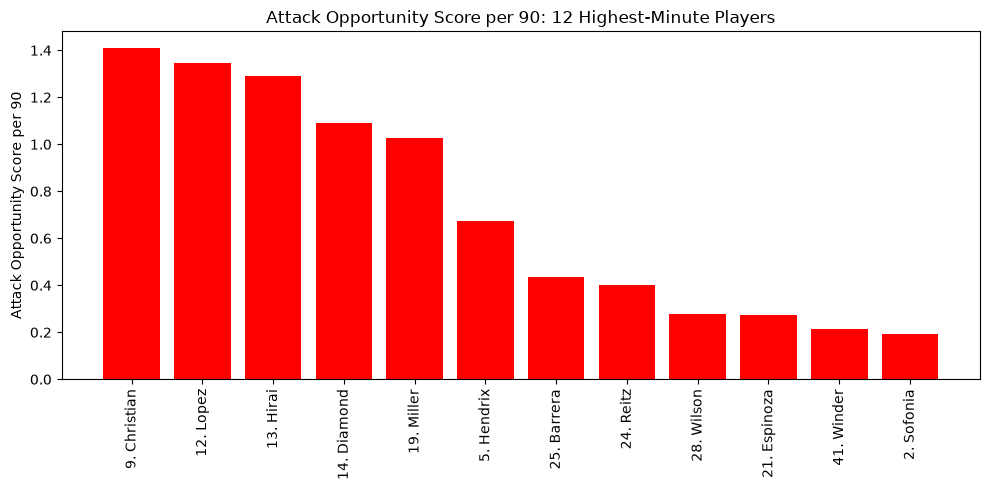

In [24]:
chain_scores_top = (
    chain_scores
    .nlargest(12, "minutes_played")
    .sort_values("score_per_90", ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    chain_scores_top["Player Code"],
    chain_scores_top["score_per_90"],
    color="red"
)

plt.xticks(rotation=90)
plt.ylabel("Attack Opportunity Score per 90")
plt.title("Attack Opportunity Score per 90: 12 Highest-Minute Players")
plt.tight_layout()
plt.show()

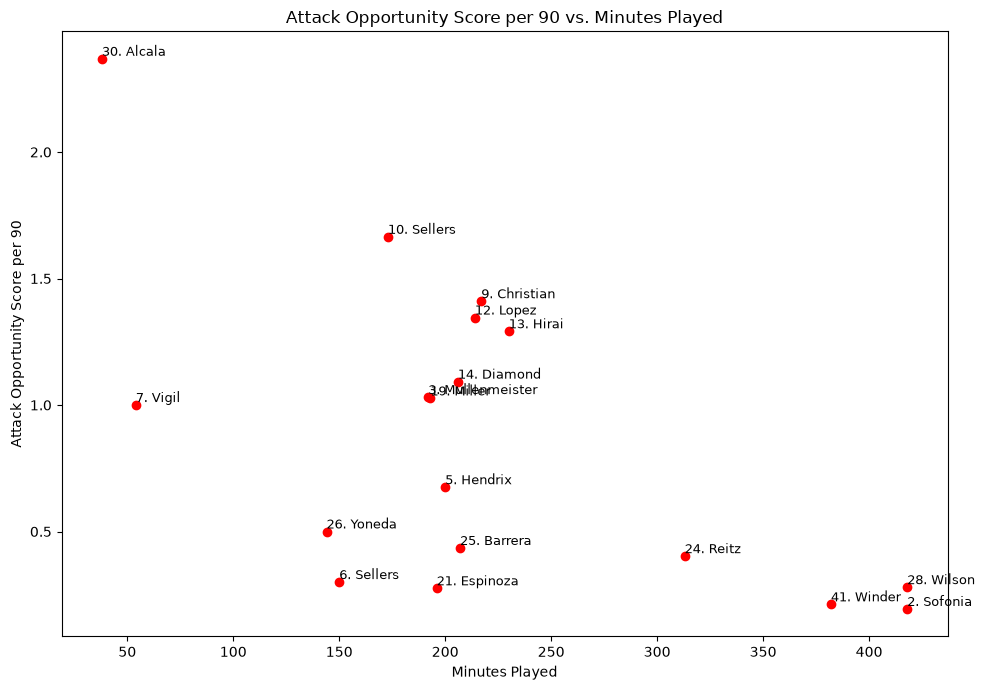

In [26]:
plt.figure(figsize=(10, 7))

plt.scatter(
    chain_scores["minutes_played"],
    chain_scores["score_per_90"],
    color="red"
)

for _, row in chain_scores.iterrows():
    plt.text(
        row["minutes_played"],
        row["score_per_90"],
        row["Player Code"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.xlabel("Minutes Played")
plt.ylabel("Attack Opportunity Score per 90")
plt.title("Attack Opportunity Score per 90 vs. Minutes Played")
plt.tight_layout()
plt.show()